# Extended CNNs: controlled tuning and experiment tracking

This notebook documents a controlled comparison of seven domain-motivated 1D-CNN architectures. All architectures first share one training protocol and three paired seeds. Seven separate Optuna studies then search architecture-specific model parameters together with a common training space under equal trial budgets, while MLflow records the trials. The best proposal from each architecture is repeated across three seeds and exported as a reload-verified model candidate.

`train` is used for fitting. The `validate` fold is named *tune* and is used for early stopping, hyperparameter selection and diagnostics. The test fold is not loaded. Repeated use of tune makes the search and confirmation estimates optimistic. Notebook 03 performs the subsequent candidate comparison and one-time test evaluation; Notebook 04 uses the frozen Extended-CNN selection for explainability.

## Contents

| Section | Documented content |
|---|---|
| [1. Protocol and fixed folds](#protocol) | Fixed data, metrics, seeds and training conditions |
| [2. Architecture map](#architecture-map) | Temporal inductive biases represented by each architecture |
| [3. Controlled screening](#screening) | Performance, variation, runtime and size under identical training |
| [4. Optuna and MLflow setup](#tracking) | Recorded conditional search space and equal trial budgets |
| [5. Per-architecture hyperparameter search](#search) | Search outcomes for model and training configurations |
| [6. Trial analysis](#trial-analysis) | Ranking, capacity, cost, pruning and parameter associations |
| [7. Multi-seed confirmation](#confirmation) | Seed stability of the best per-architecture proposals |
| [8. Matched-capacity study](#capacity-study) | Parameter efficiency of First Difference versus the standard CNN |
| [9. Candidate artifacts](#candidate-artifacts) | Reload-verified models exposed to Notebook 03 |
| [10. Conclusions](#conclusions) | Consolidated findings and scope of the experiment |

<a id="protocol"></a>
## 1. Protocol and fixed folds

In [1]:
from contextlib import redirect_stdout
from dataclasses import replace
from functools import partial
from io import StringIO
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from pytorch_timecourse_classification.analysis import evaluate_classifier, plot_history_comparison
from pytorch_timecourse_classification.artifacts import artifact_root
from pytorch_timecourse_classification.data import load_training_folds
from pytorch_timecourse_classification.experiments import create_model, fit_model, save_and_verify_experiment
from pytorch_timecourse_classification.models.cnn import CNNClassifier, scaled_cnn_config
from pytorch_timecourse_classification.models.extended_cnns import ExtendedCNNClassifier
from pytorch_timecourse_classification.tracking import MLflowTrackingConfig
from pytorch_timecourse_classification.training import TrainingConfig
from pytorch_timecourse_classification.tuning import (
    AblationSpec, OptunaScanConfig, extended_cnn_search_space_frame,
    optuna_parameter_importances, run_ablations, run_optuna_scan,
    save_ablation_study, suggest_extended_cnn_model_config,
    suggest_extended_cnn_training_config, summarize_ablations,
)

In [2]:
train_fold, tune_fold, preprocessor = load_training_folds()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_labels = np.arange(len(preprocessor.class_names))
for fold_name, fold in (("train", train_fold), ("tune (validate)", tune_fold)):
    counts = np.bincount(fold.targets.numpy(), minlength=len(class_labels))
    print(f"{fold_name:>15}: {tuple(fold.features.shape)}, {dict(zip(preprocessor.class_names, counts))}")
print(f"device: {device}")

          train: (2790, 1, 289), {'0pM': np.int64(286), '1pM': np.int64(621), '2.5pM': np.int64(533), '5pM': np.int64(487), '25pM': np.int64(581), '100pM': np.int64(282)}
tune (validate): (349, 1, 289), {'0pM': np.int64(36), '1pM': np.int64(78), '2.5pM': np.int64(66), '5pM': np.int64(62), '25pM': np.int64(72), '100pM': np.int64(35)}
device: cuda


In [3]:
ARCHITECTURES = (
    "first_difference", "fft", "gated_fusion", "multi_scale",
    "tcn", "shift_robust", "ordinal",
)
SCREENING_SEEDS = (42, 43, 44)
CONFIRMATION_SEEDS = (42, 43, 44)
BASE_MODEL_CONFIG = {
    "architecture": "first_difference", "branch_channels": (24, 48, 64),
    "kernel_sizes": (9, 7, 5), "dilations": (1, 2, 4),
    "hidden_dims": (128, 32), "dropout": 0.30, "adaptive_pool_size": 4,
}
BASE_TRAINING_CONFIG = TrainingConfig(
    epochs=140, batch_size=256, learning_rate=5e-4, weight_decay=5e-4,
    scheduler_strategy="step", scheduler_step_size=15, learning_rate_decay=0.80,
    patience=20, report_every=20, class_balance_strategy="weighted_loss",
    gradient_clip_norm=1.0,
)
EXPERIMENT_ROOT = artifact_root() / "experiments" / "extended_cnns"
EXPERIMENT_ROOT.mkdir(parents=True, exist_ok=True)
print("Shared screening model config:", BASE_MODEL_CONFIG)
print("Shared screening training config:", BASE_TRAINING_CONFIG)
print("Experiment root:", EXPERIMENT_ROOT)

Shared screening model config: {'architecture': 'first_difference', 'branch_channels': (24, 48, 64), 'kernel_sizes': (9, 7, 5), 'dilations': (1, 2, 4), 'hidden_dims': (128, 32), 'dropout': 0.3, 'adaptive_pool_size': 4}
Shared screening training config: TrainingConfig(epochs=140, batch_size=256, learning_rate=0.0005, weight_decay=0.0005, scheduler_step_size=15, learning_rate_decay=0.8, scheduler_strategy='step', warmup_epochs=0, warmup_start_factor=0.1, minimum_learning_rate=1e-06, patience=20, report_every=20, random_seed=42, class_balance_strategy='weighted_loss', gradient_clip_norm=1.0)
Experiment root: /home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/experiments/extended_cnns


### Interpretation

The experiment uses 2,790 training trajectories and 349 fixed tuning trajectories across six dose classes. Screening changes only the architecture label; folds, optimizer settings and seeds 42–44 remain paired. Parameter counts still vary because each inductive bias introduces a different computation graph. Macro-F1 is the primary metric, so every dose class contributes equally despite unequal class counts. The later Optuna stage is a joint search rather than a causal architecture ablation.

<a id="architecture-map"></a>
## 2. Architecture map

| Architecture | Inductive bias | Compact schema |
|---|---|---|
| First-Difference | absolute levels and local slopes are complementary | `x → CNN ┐; Δx → CNN ┴→ head` |
| FFT | global frequency content complements temporal features | `x, Δx, log|rFFT(x)| → CNNs → head` |
| Gated Fusion | learn when raw values or derivatives matter | `g·f_raw + (1−g)·f_Δ → head` |
| Multi-Scale | motifs of different duration occur in parallel | `Conv(k=3/7/15) → concat → head` |
| TCN | dilations connect distant time points | `ResConv(d=1/2/4) → GAP → head` |
| Shift-Robust | motif presence matters more than exact position | `stride-1 CNN → GAP → head` |
| Ordinal | dose labels have an ordered geometry | `CNN → latent score → ordered centers` |

<a id="screening"></a>
## 3. Controlled architecture screening

In [4]:
screening_specs = tuple(
    AblationSpec(
        name=architecture, model_config={**BASE_MODEL_CONFIG, "architecture": architecture},
        training_config=BASE_TRAINING_CONFIG, random_seeds=SCREENING_SEEDS,
    )
    for architecture in ARCHITECTURES
)
screening_results, screening_runs = run_ablations(
    screening_specs, model_type=ExtendedCNNClassifier, training_fold=train_fold,
    tuning_fold=tune_fold, preprocessor=preprocessor, device=device,
)
screening_summary = summarize_ablations(screening_runs)
save_ablation_study(EXPERIMENT_ROOT / "screening", results=screening_results, frame=screening_runs, summary=screening_summary)
screening_summary.round(4)

model_config: {'input_length': 289, 'num_classes': 6, 'architecture': 'first_difference', 'branch_channels': (24, 48, 64), 'kernel_sizes': (9, 7, 5), 'dilations': (1, 2, 4), 'hidden_dims': (128, 32), 'dropout': 0.3, 'adaptive_pool_size': 4, 'multi_scale_kernel_sizes': (3, 7, 15), 'ordinal_temperature': 1.0}
trainable parameters: 127,174
training_config: TrainingConfig(epochs=140, batch_size=256, learning_rate=0.0005, weight_decay=0.0005, scheduler_step_size=15, learning_rate_decay=0.8, scheduler_strategy='step', warmup_epochs=0, warmup_start_factor=0.1, minimum_learning_rate=1e-06, patience=20, report_every=20, random_seed=42, class_balance_strategy='weighted_loss', gradient_clip_norm=1.0)
epoch   1: train loss 1.56135, validation loss 1.73701, train accuracy 36.8%, validation accuracy 28.1%
epoch  20: train loss 0.81768, validation loss 0.86136, train accuracy 66.6%, validation accuracy 64.2%
epoch  40: train loss 0.65617, validation loss 0.75077, train accuracy 71.5%, validation accu

,runs,failed_runs,tune_loss_mean,tune_loss_std,tune_accuracy_mean,tune_accuracy_std,tune_macro_f1_mean,tune_macro_f1_std,macro_f1_delta_mean,macro_f1_delta_std,macro_f1_gap_mean,best_epoch_mean,best_epoch_std,convergence_epoch_95_mean,post_best_degradation_mean,tune_loss_roughness_mean,duration_seconds_mean
name,,,,,,,,,,,,,,,,,
gated_fusion,3,0,0.7205,0.0158,0.7039,0.0060,0.7130,0.0068,NaN,NaN,0.0405,66.0000,8.8882,37.6667,0.0088,0.0144,9.5004
first_difference,3,0,0.7116,0.0257,0.6944,0.0186,0.7017,0.0168,NaN,NaN,0.0608,82.6667,26.3122,42.0000,0.0119,0.0134,11.4083
fft,3,0,0.7372,0.0072,0.6934,0.0076,0.7001,0.0107,NaN,NaN,0.0731,78.3333,8.7369,36.6667,0.0171,0.0136,12.9537
tcn,3,0,0.7339,0.0078,0.6839,0.0195,0.6838,0.0246,NaN,NaN,0.0829,81.0000,16.0935,55.3333,0.1748,0.1835,25.9983
multi_scale,3,0,0.9328,0.0086,0.5922,0.0072,0.6034,0.0083,NaN,NaN,-0.0073,133.6667,7.7675,83.6667,0.0077,0.0246,11.7588
shift_robust,3,0,0.9336,0.0319,0.5826,0.0314,0.5887,0.0340,NaN,NaN,0.0425,123.6667,14.1539,73.6667,0.0193,0.0364,12.9472
ordinal,3,0,1.1667,0.0246,0.5024,0.0158,0.5036,0.0170,NaN,NaN,-0.0010,133.0000,5.2915,95.0000,0.0068,0.0139,12.1944


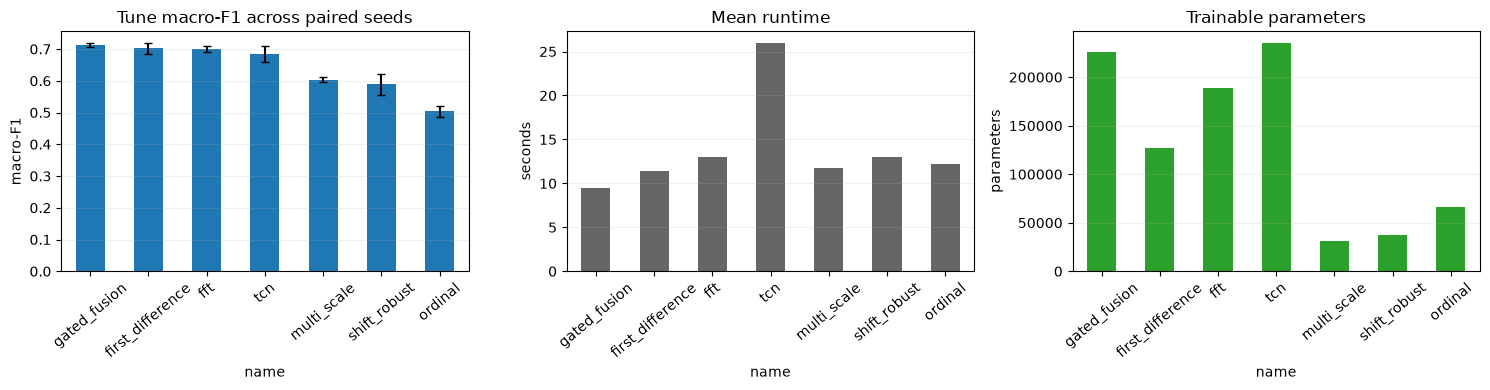

In [6]:
figure, axes = plt.subplots(1, 3, figsize=(15, 4))
order = screening_summary.index
screening_summary.loc[order, "tune_macro_f1_mean"].plot.bar(yerr=screening_summary.loc[order, "tune_macro_f1_std"], ax=axes[0], capsize=3)
screening_summary.loc[order, "duration_seconds_mean"].plot.bar(ax=axes[1], color="0.4")
screening_runs.groupby("name")["parameter_count"].first().loc[order].plot.bar(ax=axes[2], color="tab:green")
axes[0].set(title="Tune macro-F1 across paired seeds", ylabel="macro-F1")
axes[1].set(title="Mean runtime", ylabel="seconds")
axes[2].set(title="Trainable parameters", ylabel="parameters")
for axis in axes:
    axis.tick_params(axis="x", labelrotation=40); axis.grid(axis="y", alpha=0.2)
figure.tight_layout()

### Interpretation

Under the shared protocol, gated fusion leads with tune macro-F1 $0.713 \pm 0.007$, followed by first difference at $0.702 \pm 0.017$ and FFT at $0.700 \pm 0.011$. TCN reaches $0.684 \pm 0.025$ but averages 26.0 seconds per run, compared with 9.5 seconds for gated fusion. Multi-scale, shift-robust and ordinal start markedly lower at 0.603, 0.589 and 0.504.

The ranking does not follow parameter count alone: gated fusion has 225,734 parameters, first difference 127,174 and FFT 188,374, while the 235,430-parameter TCN ranks fourth. The three-seed variation overlaps for several leading architectures, so the screening establishes a performance tier rather than a decisive winner. All seven architectures remain in the subsequent equal-budget search, preserving evidence about how much of the initial gap is optimization-dependent.

<a id="tracking"></a>
## 4. Optuna and MLflow setup

Optuna proposes configurations within seven architecture-specific search spaces and prunes weak trials. Each study has the same budget of 25 attempted trials. MLflow records the proposed configuration, epoch metrics, restored-checkpoint metrics and trial status. Search files reside below `artifacts/experiments/extended_cnns`, outside the `extended_cnn_` candidate namespace used by Notebook 03.

The recorded run used the optional `torch` and `experiment` dependency groups from the project environment.

In [7]:
optuna_root = EXPERIMENT_ROOT / "optuna"
optuna_root.mkdir(parents=True, exist_ok=True)
TRIALS_PER_ARCHITECTURE = 25
OPTUNA_STORAGE = f"sqlite:///{optuna_root / 'per_architecture_studies.db'}"
SEARCH_TRAINING_CONFIG = TrainingConfig(
    epochs=160, batch_size=256, learning_rate=5e-4, weight_decay=5e-4,
    scheduler_strategy="step", scheduler_step_size=15, learning_rate_decay=0.80,
    patience=25, report_every=20, class_balance_strategy="weighted_loss",
    gradient_clip_norm=1.0,
)
display(extended_cnn_search_space_frame())
print(f"Budget: {TRIALS_PER_ARCHITECTURE} attempted trials per architecture")

values
scope            parameter                                                             
training         learning_rate                                           (5e-05, 0.001)
                 use_weight_decay                                         (False, True)
                 weight_decay                                            (1e-06, 0.001)
                 scheduler                          (none, step, cosine, warmup_cosine)
                 scheduler_step_size                                (8, 12, 16, 20, 24)
                 learning_rate_decay                                         (0.5, 0.9)
                 warmup_epochs                                           (3, 5, 10, 15)
                 batch_size                                          (32, 64, 128, 256)
                 class_balance_strategy         (none, weighted_loss, balanced_sampler)
                 gradient_clip_norm                                    (None, 1.0, 5.0)
model.common     head_depth                                                      (1, 2)
                 head_width.branch_models                           (64, 128, 256, 512)
                 head_width.specialized_models                       (32, 64, 128, 256)
                 dropout.first_difference                                   (0.05, 0.4)
                 dropout.fft                                                 (0.1, 0.4)
                 dropout.gated_fusion                                       (0.1, 0.35)
                 dropout.multi_scale                                        (0.05, 0.5)
                 dropout.tcn                                               (0.05, 0.45)
                 dropout.shift_robust                                      (0.05, 0.45)
                 dropout.ordinal                                            (0.05, 0.4)
first_difference depth                                                           (2, 4)
                 width_profile                                 (narrow, balanced, wide)
                 kernel_profile                       (local, mixed, broad, very_broad)
                 dilation_profile                                   (none, progressive)
                 adaptive_pool_size                                        (1, 2, 4, 8)
fft              depth                                                           (2, 4)
                 width_profile                                 (narrow, balanced, wide)
                 kernel_profile                       (local, mixed, broad, very_broad)
                 dilation_profile                                   (none, progressive)
                 adaptive_pool_size                                        (1, 2, 4, 8)
gated_fusion     depth                                                           (2, 4)
                 width_profile                                 (narrow, balanced, wide)
                 kernel_profile                       (local, mixed, broad, very_broad)
                 dilation_profile                                   (none, progressive)
                 adaptive_pool_size                                        (1, 2, 4, 8)
ordinal          depth                                                           (2, 4)
                 width_profile                                 (narrow, balanced, wide)
                 kernel_profile                       (local, mixed, broad, very_broad)
                 dilation_profile                                   (none, progressive)
                 adaptive_pool_size                                        (1, 2, 4, 8)
                 ordinal_temperature                                         (0.4, 2.0)
multi_scale      output_channels                                  (24, 48, 64, 96, 128)
                 multi_scale_profile             (compact, balanced, broad, very_broad)
tcn              blocks                                                          (2, 5)
                 width           

Budget: 25 attempted trials per architecture


### Interpretation

The displayed boundaries are generated from `EXTENDED_CNN_TRAINING_SEARCH_SPACE`, `EXTENDED_CNN_COMMON_MODEL_SEARCH_SPACE` and `EXTENDED_CNN_ARCHITECTURE_SEARCH_SPACES` in `tuning.py`. Training choices include learning rate, weight decay, scheduler, batch size, class balancing and gradient clipping. Model choices include head depth and width, dropout, and architecture-specific depth, width, receptive-field or pooling parameters.

All studies retain the same folds, Macro-F1 objective, 160-epoch ceiling, patience of 25 and pruning warm-up of 15 epochs. The stored results correspond exactly to these boundaries. The search space was not widened after the separate standard-CNN scaling experiment, so the completed trials remain internally consistent with their documentation.

<a id="search"></a>
## 5. Per-architecture hyperparameter search

In [8]:
studies = {}
for architecture in ARCHITECTURES:
    tracking_config = MLflowTrackingConfig.local(
        EXPERIMENT_ROOT / "mlflow", experiment_name="timecourse-extended-cnns",
        parent_run_name=f"{architecture}-search",
    )
    scan_config = OptunaScanConfig(
        scope="joint", n_trials=TRIALS_PER_ARCHITECTURE, n_trials_mode="total",
        study_name=f"extended-cnn-{architecture}-v1", storage=OPTUNA_STORAGE,
        sampler_seed=42, trial_seed=42, n_startup_trials=5,
        pruning_warmup_epochs=15,
    )
    study = run_optuna_scan(
        model_type=ExtendedCNNClassifier, base_model_config={
            **BASE_MODEL_CONFIG, "architecture": architecture,
        },
        base_training_config=SEARCH_TRAINING_CONFIG, training_fold=train_fold,
        tuning_fold=tune_fold, preprocessor=preprocessor, device=device,
        scan_config=scan_config, model_config_suggester=partial(
            suggest_extended_cnn_model_config, architectures=(architecture,),
        ), training_config_suggester=suggest_extended_cnn_training_config,
        mlflow_tracking=tracking_config,
    )
    studies[architecture] = study
    print(architecture, "trials:", len(study.trials), "best tune macro-F1:", study.best_value)

/home/lorenz/Environments/DeeplearningExamples/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-08-21 23:01:43,179] A new study created in RDB with name: extended-cnn-first_difference-v1


model_config: {'input_length': 289, 'num_classes': 6, 'architecture': 'first_difference', 'branch_channels': (20, 40, 64, 96), 'kernel_sizes': (5, 3, 3, 3), 'dilations': (1, 2, 4, 8), 'hidden_dims': (128,), 'dropout': 0.07032926425886982, 'adaptive_pool_size': 8, 'multi_scale_kernel_sizes': (3, 7, 15), 'ordinal_temperature': 1.0}
trainable parameters: 275,798
training_config: TrainingConfig(epochs=160, batch_size=64, learning_rate=7.593739613361245e-05, weight_decay=2.334586407601622e-05, scheduler_step_size=15, learning_rate_decay=0.8, scheduler_strategy='none', warmup_epochs=0, warmup_start_factor=0.1, minimum_learning_rate=1e-06, patience=25, report_every=20, random_seed=42, class_balance_strategy='weighted_loss', gradient_clip_norm=5.0)
epoch   1: train loss 1.39576, validation loss 1.38070, train accuracy 41.2%, validation accuracy 35.2%
epoch  20: train loss 0.60900, validation loss 0.79924, train accuracy 74.8%, validation accuracy 68.5%
epoch  40: train loss 0.42034, validation

[I 2026-08-21 23:02:03,468] Trial 0 finished with value: 0.6820006095245442 and parameters: {'model.architecture': 'first_difference', 'model.head_width': 128, 'model.head_depth': 1, 'model.dropout': 0.07032926425886982, 'model.depth': 4, 'model.width_profile': 'balanced', 'model.kernel_profile': 'local', 'model.dilation_profile': 'progressive', 'model.adaptive_pool_size': 8, 'training.learning_rate': 7.593739613361245e-05, 'training.use_weight_decay': True, 'training.weight_decay': 2.334586407601622e-05, 'training.scheduler': 'none', 'training.batch_size': 64, 'training.class_balance_strategy': 'weighted_loss', 'training.gradient_clip_norm': 5.0}. Best is trial 0 with value: 0.6820006095245442.


Early stopping after epoch 59.
model_config: {'input_length': 289, 'num_classes': 6, 'architecture': 'first_difference', 'branch_channels': (20, 40), 'kernel_sizes': (5, 3), 'dilations': (1, 2), 'hidden_dims': (256,), 'dropout': 0.2818827995238937, 'adaptive_pool_size': 8, 'multi_scale_kernel_sizes': (3, 7, 15), 'ordinal_temperature': 1.0}
trainable parameters: 173,270
training_config: TrainingConfig(epochs=160, batch_size=64, learning_rate=0.00016019568611465226, weight_decay=1.1756010900231857e-05, scheduler_step_size=15, learning_rate_decay=0.8, scheduler_strategy='warmup_cosine', warmup_epochs=5, warmup_start_factor=0.1, minimum_learning_rate=1e-06, patience=25, report_every=20, random_seed=42, class_balance_strategy='none', gradient_clip_norm=1.0)
epoch   1: train loss 1.82245, validation loss 1.70727, train accuracy 22.0%, validation accuracy 27.5%
epoch  20: train loss 0.74074, validation loss 0.77876, train accuracy 68.5%, validation accuracy 65.9%
epoch  40: train loss 0.62260

[I 2026-08-21 23:02:29,652] Trial 1 finished with value: 0.6832512365617226 and parameters: {'model.architecture': 'first_difference', 'model.head_width': 256, 'model.head_depth': 1, 'model.dropout': 0.2818827995238937, 'model.depth': 2, 'model.width_profile': 'balanced', 'model.kernel_profile': 'local', 'model.dilation_profile': 'progressive', 'model.adaptive_pool_size': 8, 'training.learning_rate': 0.00016019568611465226, 'training.use_weight_decay': True, 'training.weight_decay': 1.1756010900231857e-05, 'training.scheduler': 'warmup_cosine', 'training.warmup_epochs': 5, 'training.batch_size': 64, 'training.class_balance_strategy': 'none', 'training.gradient_clip_norm': 1.0}. Best is trial 1 with value: 0.6832512365617226.


...

Early stopping after epoch 57.
model_config: {'input_length': 289, 'num_classes': 6, 'architecture': 'ordinal', 'branch_channels': (32, 64, 96), 'kernel_sizes': (9, 7, 5), 'dilations': (1, 1, 1), 'hidden_dims': (512, 128), 'dropout': 0.13496157506176557, 'adaptive_pool_size': 2, 'multi_scale_kernel_sizes': (3, 7, 15), 'ordinal_temperature': 0.8030285043156127}
trainable parameters: 220,231
training_config: TrainingConfig(epochs=160, batch_size=32, learning_rate=0.0009736201072590437, weight_decay=0.0, scheduler_step_size=15, learning_rate_decay=0.8, scheduler_strategy='none', warmup_epochs=0, warmup_start_factor=0.1, minimum_learning_rate=1e-06, patience=25, report_every=20, random_seed=42, class_balance_strategy='none', gradient_clip_norm=None)
epoch   1: train loss 1.31752, validation loss 1.27094, train accuracy 39.0%, validation accuracy 41.5%
epoch  20: train loss 1.02763, validation loss 1.07700, train accuracy 56.2%, validation accuracy 53.0%


[I 2026-08-21 23:55:41,550] Trial 23 pruned. 


model_config: {'input_length': 289, 'num_classes': 6, 'architecture': 'ordinal', 'branch_channels': (32, 64, 96), 'kernel_sizes': (9, 7, 5), 'dilations': (1, 1, 1), 'hidden_dims': (512, 128), 'dropout': 0.1911457049058144, 'adaptive_pool_size': 2, 'multi_scale_kernel_sizes': (3, 7, 15), 'ordinal_temperature': 0.7347338647438572}
trainable parameters: 220,231
training_config: TrainingConfig(epochs=160, batch_size=32, learning_rate=0.0007972019765664539, weight_decay=0.0, scheduler_step_size=15, learning_rate_decay=0.8, scheduler_strategy='none', warmup_epochs=0, warmup_start_factor=0.1, minimum_learning_rate=1e-06, patience=25, report_every=20, random_seed=42, class_balance_strategy='none', gradient_clip_norm=None)
epoch   1: train loss 1.32893, validation loss 1.24447, train accuracy 38.1%, validation accuracy 43.0%


[I 2026-08-21 23:55:48,952] Trial 24 pruned. 


ordinal trials: 25 best tune macro-F1: 0.6465381381123106


### Interpretation

The seven studies contain 175 attempted trials: 90 complete and 85 pruned. The best single-trial macro-F1 values range from 0.641 for multi-scale to 0.716 for gated fusion. Gated fusion contributes five of the ten strongest completed trials, first difference contributes three, and FFT and TCN contribute one each. This concentration indicates repeatable strong regions for gated fusion and first difference, while the best-trial values remain subject to tune-selection optimism.

<a id="trial-analysis"></a>
## 6. Trial analysis

In [9]:
trial_frames = []
for architecture, study in studies.items():
    frame = study.trials_dataframe(
        attrs=("number", "value", "duration", "params", "user_attrs", "state")
    )
    frame.insert(0, "architecture_budget", architecture)
    trial_frames.append(frame)
trials = pd.concat(trial_frames, ignore_index=True)
trials.to_csv(EXPERIMENT_ROOT / "per_architecture_optuna_trials.csv", index=False)
budget_summary = pd.crosstab(trials["architecture_budget"], trials["state"])
display(budget_summary)
display(trials.loc[trials["state"] == "COMPLETE"].nlargest(10, "value"))

state,COMPLETE,PRUNED
architecture_budget,,
fft,11,14
first_difference,16,9
gated_fusion,15,10
multi_scale,9,16
ordinal,12,13
shift_robust,16,9
tcn,11,14


,architecture_budget,number,value,duration,params_model.adaptive_pool_size,params_model.architecture,params_model.depth,params_model.dilation_profile,params_model.dropout,params_model.head_depth,...,params_model.multi_scale_profile,params_model.output_channels,params_model.tcn_blocks,params_model.tcn_dilation_profile,params_model.tcn_kernel_size,params_model.tcn_width,params_model.shift_depth,params_model.shift_kernel_profile,params_model.shift_width_profile,params_model.ordinal_temperature
72,gated_fusion,22,0.716212,0 days 00:00:16.096398,4.0,gated_fusion,3.0,progressive,0.190360,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64,gated_fusion,14,0.715223,0 days 00:00:09.574102,4.0,gated_fusion,3.0,progressive,0.200156,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
66,gated_fusion,16,0.714299,0 days 00:00:10.675809,4.0,gated_fusion,2.0,progressive,0.179492,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57,gated_fusion,7,0.713059,0 days 00:00:12.800526,4.0,gated_fusion,3.0,progressive,0.112920,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23,first_difference,23,0.710200,0 days 00:00:21.806256,4.0,first_difference,2.0,none,0.210176,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
63,gated_fusion,13,0.707660,0 days 00:00:07.219469,4.0,gated_fusion,3.0,none,0.207655,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100,tcn,0,0.705912,0 days 00:02:22.243110,NaN,tcn,NaN,NaN,0.073233,1,...,NaN,NaN,5.0,none,9.0,96.0,NaN,NaN,NaN,NaN
9,first_difference,9,0.704827,0 days 00:00:10.604927,4.0,first_difference,2.0,none,0.148712,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,first_difference,3,0.704533,0 days 00:00:23.839361,8.0,first_difference,3.0,progressive,0.091953,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
40,fft,15,0.703464,0 days 00:00:13.550794,8.0,fft,3.0,none,0.244855,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Interpretation: trial budget and ranking

Completed-trial counts range from 9 of 25 for multi-scale to 16 of 25 for first difference and shift robust. The unequal completion counts arise from pruning rather than unequal budgets. The best search proposals are gated fusion (0.716), first difference (0.710), TCN (0.706), FFT (0.703) and shift robust (0.699). Their proximity is small enough that the later seed repetitions can plausibly reorder them.

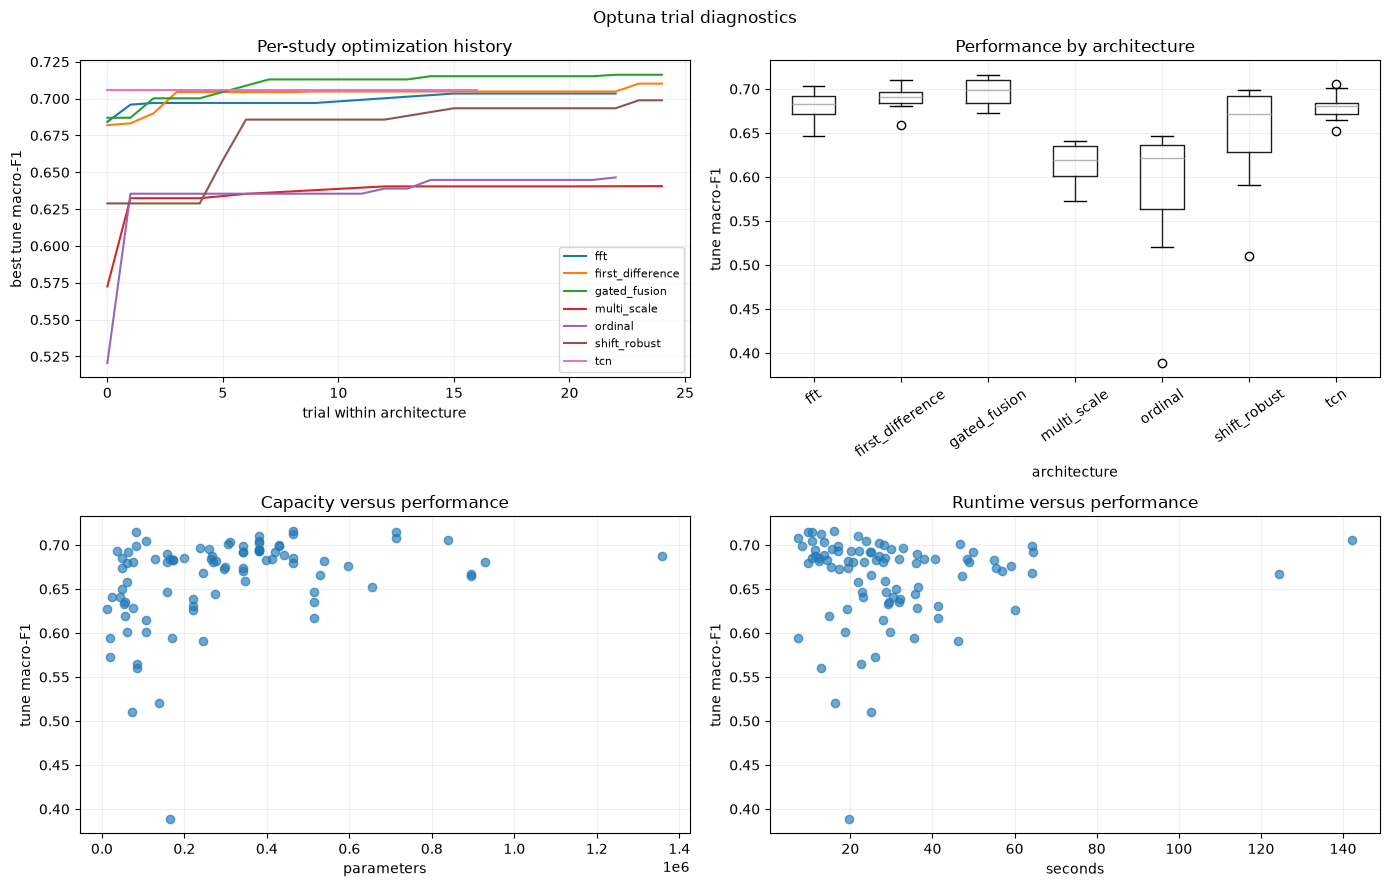

In [10]:
completed = trials.loc[trials["state"] == "COMPLETE"].copy()
completed["duration_seconds"] = completed["duration"].dt.total_seconds()
parameter_column = "user_attrs_parameter_count"
figure, axes = plt.subplots(2, 2, figsize=(14, 9))
for architecture, group in completed.groupby("architecture_budget"):
    group = group.sort_values("number")
    axes[0, 0].plot(group["number"], group["value"].cummax(), label=architecture)
axes[0, 0].set(title="Per-study optimization history", xlabel="trial within architecture", ylabel="best tune macro-F1")
axes[0, 0].legend(fontsize=8)
completed.boxplot(column="value", by="architecture_budget", ax=axes[0, 1], rot=35)
axes[0, 1].set(title="Performance by architecture", xlabel="architecture", ylabel="tune macro-F1")
axes[1, 0].scatter(completed[parameter_column], completed["value"], alpha=0.65)
axes[1, 0].set(title="Capacity versus performance", xlabel="parameters", ylabel="tune macro-F1")
axes[1, 1].scatter(completed["duration_seconds"], completed["value"], alpha=0.65)
axes[1, 1].set(title="Runtime versus performance", xlabel="seconds", ylabel="tune macro-F1")
for axis in axes.flat: axis.grid(alpha=0.2)
figure.suptitle("Optuna trial diagnostics"); figure.tight_layout()

### Interpretation: capacity and engineering cost

Completed trials span roughly 13 thousand to 1.36 million parameters, yet the global capacity scatter has no monotonic frontier. Within-architecture Spearman associations between parameter count and Macro-F1 are strongest for ordinal (0.77) and moderate for first difference (0.45); they are near zero for FFT (0.01) and negative for TCN (-0.31) and multi-scale (-0.32). Gated fusion and shift robust show only modest positive associations (0.25 and 0.31).

The best first-difference configuration uses the maximum searched head width of 512 and a wide convolution profile, while the best shift-robust and ordinal trials also reach their largest observed parameter counts. These boundary contacts leave architecture-specific capacity uncertainty. They do not establish a general benefit from larger models because gated fusion performs best in search below its observed maximum size, and the largest TCN trials do not dominate. Runtime also rises independently of quality: TCN is substantially slower without retaining the best confirmed score.

,first_difference,fft,gated_fusion,multi_scale,tcn,shift_robust,ordinal
model.adaptive_pool_size,0.008,0.064,0.157,0.000,0.000,0.000,0.015
model.architecture,0.000,0.000,0.000,0.000,0.000,0.000,0.000
model.depth,0.011,0.002,0.003,0.000,0.000,0.000,0.029
model.dilation_profile,0.010,0.008,0.034,0.000,0.000,0.000,0.001
model.dropout,0.068,0.165,0.175,0.314,0.285,0.275,0.045
model.head_depth,0.000,0.006,0.000,0.020,0.006,0.175,0.014
model.head_width,0.168,0.055,0.045,0.040,0.042,0.087,0.066
model.kernel_profile,0.006,0.178,0.118,0.000,0.000,0.000,0.076
model.multi_scale_profile,0.000,0.000,0.000,0.066,0.000,0.000,0.000
model.ordinal_temperature,0.000,0.000,0.000,0.000,0.000,0.000,0.136


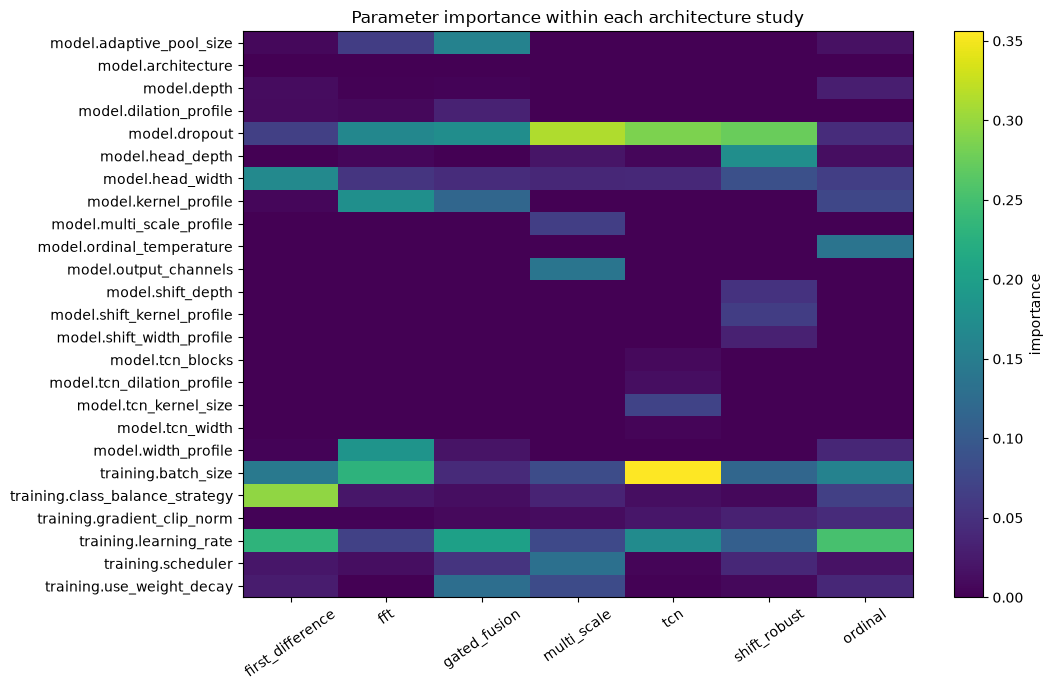

In [11]:
importance_by_architecture = {}
for architecture, study in studies.items():
    try:
        importance_by_architecture[architecture] = optuna_parameter_importances(study)
    except ValueError:
        importance_by_architecture[architecture] = pd.Series(dtype=float)
parameter_importance = pd.DataFrame(importance_by_architecture)
display(parameter_importance.fillna(0).round(3))
figure, axis = plt.subplots(figsize=(11, max(5, 0.28 * len(parameter_importance))))
image = axis.imshow(parameter_importance.fillna(0), aspect="auto", cmap="viridis")
axis.set(yticks=range(len(parameter_importance)), yticklabels=parameter_importance.index,
         xticks=range(len(parameter_importance.columns)), xticklabels=parameter_importance.columns)
axis.tick_params(axis="x", rotation=35)
axis.set_title("Parameter importance within each architecture study")
figure.colorbar(image, ax=axis, label="importance"); figure.tight_layout()

### Interpretation: parameter associations

Training choices explain a substantial share of within-study variation. Class balancing and learning rate dominate first difference; batch size and dropout dominate TCN; learning rate and dropout are prominent for gated fusion; and learning rate, batch size and ordinal temperature dominate ordinal. FFT additionally depends on convolution width and kernel profile, while multi-scale is most sensitive to dropout and output channels.

The mixture of optimizer, regularization and architecture variables among the leading importances explains why raw parameter count alone is insufficient. It also accounts for the large improvements of some initially weak architectures after joint tuning.

### Methodological interpretation

The importance values describe associations within one architecture-specific and adaptively sampled search space. They are not causal effects and are not directly comparable across studies. Equal attempted-trial budgets coexist with different numbers of completed trials because pruning responds to intermediate performance. Consequently, each best trial is treated as a tune-selected proposal, and the multi-seed confirmation provides the stronger stability estimate.

<a id="confirmation"></a>
## 7. Multi-seed confirmation

In [12]:
architecture_trials = tuple(
    sorted((study.best_trial for study in studies.values()), key=lambda trial: trial.value, reverse=True)
)
architecture_trial_table = pd.DataFrame([
    {"architecture": trial.params["model.architecture"], "trial": trial.number,
     "search_macro_f1": trial.value, "parameters": trial.user_attrs["parameter_count"],
     "attempted_trials": len(studies[trial.params["model.architecture"]].trials)}
    for trial in architecture_trials
]).set_index("architecture")
architecture_trial_table.round(4)

,trial,search_macro_f1,parameters,attempted_trials
architecture,,,,
gated_fusion,22,0.7162,463366,25
first_difference,23,0.7102,381318,25
tcn,0,0.7059,839238,25
fft,15,0.7035,311046,25
shift_robust,23,0.6989,342470,25
ordinal,22,0.6465,515143,25
multi_scale,24,0.6406,44902,25


### Interpretation: selected proposals

The seven proposals contain 44,902 to 839,238 parameters. Gated fusion leads the single-trial ranking with 0.716 at 463,366 parameters; first difference follows with 0.710 at 381,318; and TCN reaches 0.706 with the largest selected model at 839,238. The smallest proposal, multi-scale at 44,902 parameters, reaches 0.641. This ordering again separates architectural suitability from capacity alone.

In [13]:
confirmation_specs = tuple(
    AblationSpec(
        name=trial.params["model.architecture"], model_config=trial.user_attrs["model_config"],
        training_config=TrainingConfig(**trial.user_attrs["training_config"]),
        random_seeds=CONFIRMATION_SEEDS,
    )
    for trial in architecture_trials
)
confirmation_results, confirmation_runs = run_ablations(
    confirmation_specs, model_type=ExtendedCNNClassifier, training_fold=train_fold,
    tuning_fold=tune_fold, preprocessor=preprocessor, device=device,
)
confirmation_summary = summarize_ablations(confirmation_runs)
save_ablation_study(EXPERIMENT_ROOT / "confirmation", results=confirmation_results, frame=confirmation_runs, summary=confirmation_summary)
confirmation_summary.round(4)

model_config: {'input_length': 289, 'num_classes': 6, 'architecture': 'gated_fusion', 'branch_channels': (32, 64, 96), 'kernel_sizes': (5, 3, 3), 'dilations': (1, 2, 4), 'hidden_dims': (256,), 'dropout': 0.19035990126749178, 'adaptive_pool_size': 4, 'multi_scale_kernel_sizes': (3, 7, 15), 'ordinal_temperature': 1.0}
trainable parameters: 463,366
training_config: TrainingConfig(epochs=160, batch_size=64, learning_rate=0.00041565416435761297, weight_decay=0.0, scheduler_step_size=15, learning_rate_decay=0.8, scheduler_strategy='none', warmup_epochs=0, warmup_start_factor=0.1, minimum_learning_rate=1e-06, patience=25, report_every=20, random_seed=42, class_balance_strategy='weighted_loss', gradient_clip_norm=None)
epoch   1: train loss 1.14643, validation loss 1.19917, train accuracy 49.5%, validation accuracy 45.0%
epoch  20: train loss 0.46099, validation loss 0.74203, train accuracy 79.2%, validation accuracy 67.6%
epoch  40: train loss 0.30553, validation loss 0.76224, train accuracy 

,runs,failed_runs,tune_loss_mean,tune_loss_std,tune_accuracy_mean,tune_accuracy_std,tune_macro_f1_mean,tune_macro_f1_std,macro_f1_delta_mean,macro_f1_delta_std,macro_f1_gap_mean,best_epoch_mean,best_epoch_std,convergence_epoch_95_mean,post_best_degradation_mean,tune_loss_roughness_mean,duration_seconds_mean
name,,,,,,,,,,,,,,,,,
first_difference,3,0,0.7342,0.0195,0.6963,0.0050,0.7041,0.0037,NaN,NaN,0.0969,19.3333,6.3509,14.6667,0.1355,0.0671,18.2154
gated_fusion,3,0,0.7164,0.0124,0.6896,0.0158,0.6973,0.0189,NaN,NaN,0.0807,21.6667,8.1445,17.0000,0.1338,0.0364,11.6306
shift_robust,3,0,0.7165,0.0059,0.6867,0.0088,0.6939,0.0082,NaN,NaN,0.0106,62.3333,11.9304,51.0000,0.2485,0.1518,48.8404
tcn,3,0,0.7518,0.0442,0.6896,0.0211,0.6861,0.0208,NaN,NaN,0.1535,105.3333,37.8990,79.3333,0.0482,0.1987,112.7057
fft,3,0,0.7570,0.0270,0.6753,0.0230,0.6836,0.0191,NaN,NaN,0.0983,23.0000,3.4641,17.0000,0.0550,0.0234,11.1160
multi_scale,3,0,0.8463,0.0062,0.6266,0.0066,0.6379,0.0090,NaN,NaN,0.0216,138.6667,18.1475,85.3333,0.0044,0.0474,20.5889
ordinal,3,0,0.8803,0.0164,0.6237,0.0186,0.6317,0.0178,NaN,NaN,0.0816,36.0000,6.0828,36.0000,0.0709,0.0600,23.1997


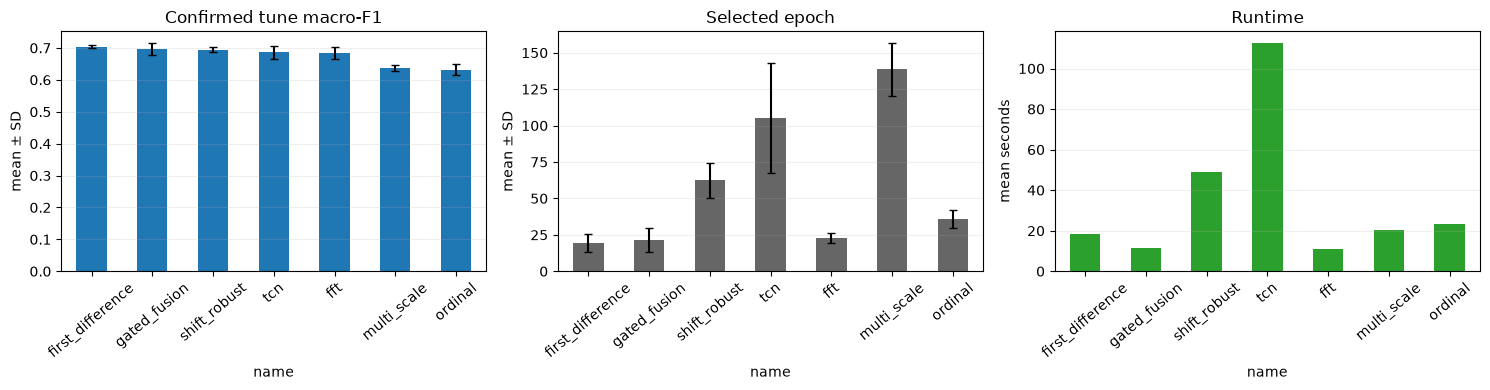

In [14]:
order = confirmation_summary.index
figure, axes = plt.subplots(1, 3, figsize=(15, 4))
confirmation_summary.loc[order, "tune_macro_f1_mean"].plot.bar(yerr=confirmation_summary.loc[order, "tune_macro_f1_std"], ax=axes[0], capsize=3)
confirmation_summary.loc[order, "best_epoch_mean"].plot.bar(yerr=confirmation_summary.loc[order, "best_epoch_std"], ax=axes[1], capsize=3, color="0.4")
confirmation_summary.loc[order, "duration_seconds_mean"].plot.bar(ax=axes[2], color="tab:green")
axes[0].set(title="Confirmed tune macro-F1", ylabel="mean ± SD")
axes[1].set(title="Selected epoch", ylabel="mean ± SD")
axes[2].set(title="Runtime", ylabel="mean seconds")
for axis in axes: axis.tick_params(axis="x", labelrotation=40); axis.grid(axis="y", alpha=0.2)
figure.tight_layout()

### Interpretation

Across seeds 42–44, first difference has the highest mean tune macro-F1 at $0.704 \pm 0.004$. Gated fusion reaches $0.697 \pm 0.019$ and shift robust $0.694 \pm 0.008$; their uncertainty overlaps the leading score. TCN and FFT fall to $0.686 \pm 0.021$ and $0.684 \pm 0.019$, while multi-scale and ordinal remain lower at 0.638 and 0.632.

Confirmation reduces the best-trial score for every architecture by approximately 0.003–0.020, quantifying selection optimism. First difference is the most stable leader but has a mean train–tune Macro-F1 gap of 0.097 and selects epoch 19 on average. Gated fusion has a gap of 0.081 and selects epoch 22; shift robust has the smallest leading-group gap at 0.011 but rougher validation trajectories and a mean runtime of 48.8 seconds. TCN is the most expensive at 112.7 seconds per confirmation run and has the largest gap, 0.153.

### Selection scope

The confirmation ranking is more stable than the single-trial ranking because it exposes initialization sensitivity. It still reuses the tune fold already seen by Optuna and therefore is not an independent generalization estimate. Notebook 03 scores the exported checkpoints, freezes the family winner and the top three Extended CNNs, and then evaluates the test fold once.

<a id="capacity-study"></a>
## 8. Matched-capacity study: First Difference versus CNN

This study isolates parameter efficiency at the full training-data size. A standard CNN and a First-Difference CNN are compared at six approximately matched budgets from about 4 thousand to 4.07 million trainable parameters. The First-Difference template retains the broad two-layer kernels and raw-plus-derivative branches selected by Optuna; only branch and head widths change. Dropout and the complete training protocol are shared between families.

For every family-budget pair, learning rate is selected from $10^{-4}$, $3 	imes 10^{-4}$ and $10^{-3}$ using seed 42 and minimum tune loss. The selected configuration is then evaluated with seeds 42–44. Seed 42 is reused from the learning-rate sweep. This design measures capacity efficiency under one shared protocol; it does not separate every architectural detail from the derivative representation and still reuses the tune fold.

In [18]:
CAPACITY_LEVELS = ("B1", "B2", "B3", "B4", "B5", "B6")
CNN_CAPACITY_WIDTHS = (0.25, 0.5, 1.0, 2.0, 4.0, 8.0)
FIRST_DIFFERENCE_CAPACITY_WIDTHS = (0.105, 0.20, 0.41, 0.82, 1.64, 3.28)
CAPACITY_LEARNING_RATES = (1e-4, 3e-4, 1e-3)
CAPACITY_SEEDS = (42, 43, 44)
CAPACITY_RECOMPUTE = False
CAPACITY_ROOT = EXPERIMENT_ROOT / "capacity_efficiency"
CAPACITY_ROOT.mkdir(parents=True, exist_ok=True)

CNN_CAPACITY_TEMPLATE = {
    "kernel_sizes": (9, 7, 5), "dilations": (1, 1, 1),
    "pool_size": 2, "dropout": 0.2, "residual": False,
}
FIRST_DIFFERENCE_CAPACITY_TEMPLATE = {
    "architecture": "first_difference",
    "branch_channels": (32, 64), "kernel_sizes": (15, 11),
    "dilations": (1, 1), "hidden_dims": (512, 128),
    "dropout": 0.2, "adaptive_pool_size": 4,
    "multi_scale_kernel_sizes": (3, 7, 15), "ordinal_temperature": 1.0,
}
CAPACITY_TRAINING_TEMPLATE = TrainingConfig(
    epochs=200, batch_size=128, learning_rate=3e-4, weight_decay=1e-4,
    scheduler_strategy="none", patience=5, report_every=200,
    random_seed=42, class_balance_strategy="none", gradient_clip_norm=1.0,
)

def scaled_first_difference_config(width_multiplier):
    config = dict(FIRST_DIFFERENCE_CAPACITY_TEMPLATE)
    config["branch_channels"] = tuple(
        max(1, round(value * width_multiplier))
        for value in FIRST_DIFFERENCE_CAPACITY_TEMPLATE["branch_channels"]
    )
    config["hidden_dims"] = tuple(
        max(1, round(value * width_multiplier))
        for value in FIRST_DIFFERENCE_CAPACITY_TEMPLATE["hidden_dims"]
    )
    return config

def capacity_model_spec(family, level_index):
    if family == "cnn":
        return CNNClassifier, {
            **CNN_CAPACITY_TEMPLATE,
            **scaled_cnn_config(CNN_CAPACITY_WIDTHS[level_index]),
        }
    return ExtendedCNNClassifier, scaled_first_difference_config(
        FIRST_DIFFERENCE_CAPACITY_WIDTHS[level_index]
    )

capacity_budget_rows = []
for family in ("cnn", "first_difference"):
    for level_index, capacity_level in enumerate(CAPACITY_LEVELS):
        model_type, model_config = capacity_model_spec(family, level_index)
        model = model_type(
            input_length=train_fold.features.shape[-1],
            num_classes=len(preprocessor.class_names), **model_config,
        )
        capacity_budget_rows.append({
            "family": family, "capacity_level": capacity_level,
            "width_multiplier": (
                CNN_CAPACITY_WIDTHS[level_index] if family == "cnn"
                else FIRST_DIFFERENCE_CAPACITY_WIDTHS[level_index]
            ),
            "parameter_count": sum(
                parameter.numel() for parameter in model.parameters()
                if parameter.requires_grad
            ),
        })
capacity_budget_table = pd.DataFrame(capacity_budget_rows)
display(capacity_budget_table)

,family,capacity_level,width_multiplier,parameter_count
0,cnn,B1,0.250,4326
1,cnn,B2,0.500,16582
2,cnn,B3,1.000,64902
3,cnn,B4,2.000,256774
4,cnn,B5,4.000,1021446
5,cnn,B6,8.000,4074502
6,first_difference,B1,0.105,4691
7,first_difference,B2,0.200,16022
8,first_difference,B3,0.410,64544
9,first_difference,B4,0.820,254935


### Interpretation: matched budgets

The first budget contains 4,326 CNN parameters and 4,691 First-Difference parameters, an 8.4% mismatch caused by integer channel widths. From B2 onward the mismatch is at most 3.4%, and from B3 onward it is below 1%. Differences in held-out performance can therefore be interpreted against effectively equal parameter budgets rather than against the much larger parameter counts of the previously exported models.

In [19]:
def fit_capacity_cell(family, level_index, learning_rate, random_seed):
    model_type, model_config = capacity_model_spec(family, level_index)
    with redirect_stdout(StringIO()):
        model, parameter_count = create_model(
            model_type, input_length=train_fold.features.shape[-1],
            num_classes=len(preprocessor.class_names), random_seed=random_seed,
            **model_config,
        )
        started = perf_counter()
        history = fit_model(
            model,
            replace(
                CAPACITY_TRAINING_TEMPLATE,
                learning_rate=learning_rate, random_seed=random_seed,
            ),
            training_fold=train_fold, tuning_fold=tune_fold, device=device,
        )
    best_index = history.best_epoch - 1
    return {
        "family": family,
        "capacity_level": CAPACITY_LEVELS[level_index],
        "width_multiplier": (
            CNN_CAPACITY_WIDTHS[level_index] if family == "cnn"
            else FIRST_DIFFERENCE_CAPACITY_WIDTHS[level_index]
        ),
        "parameter_count": parameter_count,
        "learning_rate": learning_rate,
        "random_seed": random_seed,
        "best_epoch": history.best_epoch,
        "epochs_run": len(history.validation_loss),
        "training_loss": history.training_loss[best_index],
        "tune_loss": history.validation_loss[best_index],
        "training_accuracy": history.training_accuracy[best_index],
        "tune_accuracy": history.validation_accuracy[best_index],
        "training_macro_f1": history.training_macro_f1[best_index],
        "tune_macro_f1": history.validation_macro_f1[best_index],
        "macro_f1_gap": (
            history.training_macro_f1[best_index]
            - history.validation_macro_f1[best_index]
        ),
        "duration_seconds": perf_counter() - started,
    }

grid_path = CAPACITY_ROOT / "learning_rate_grid.csv"
expected_grid_keys = {
    (family, level, learning_rate)
    for family in ("cnn", "first_difference")
    for level in CAPACITY_LEVELS
    for learning_rate in CAPACITY_LEARNING_RATES
}
capacity_grid = pd.read_csv(grid_path) if grid_path.is_file() else None
cached_grid_keys = set() if capacity_grid is None else set(zip(
    capacity_grid["family"], capacity_grid["capacity_level"],
    capacity_grid["learning_rate"],
))
if CAPACITY_RECOMPUTE or cached_grid_keys != expected_grid_keys:
    capacity_grid = pd.DataFrame([
        fit_capacity_cell(family, level_index, learning_rate, 42)
        for family in ("cnn", "first_difference")
        for level_index in range(len(CAPACITY_LEVELS))
        for learning_rate in CAPACITY_LEARNING_RATES
    ])
    capacity_grid.to_csv(grid_path, index=False)
else:
    print("loaded cached learning-rate grid:", grid_path)

capacity_selected = (
    capacity_grid.sort_values(["family", "capacity_level", "tune_loss"])
    .groupby(["family", "capacity_level"], as_index=False).first()
)
capacity_selected.to_csv(CAPACITY_ROOT / "selected_seed42.csv", index=False)

confirmation_path = CAPACITY_ROOT / "confirmation_runs.csv"
capacity_confirmation = (
    pd.read_csv(confirmation_path) if confirmation_path.is_file() else None
)
expected_confirmation_keys = {
    (family, level, seed)
    for family in ("cnn", "first_difference")
    for level in CAPACITY_LEVELS for seed in CAPACITY_SEEDS
}
cached_confirmation_keys = set() if capacity_confirmation is None else set(zip(
    capacity_confirmation["family"], capacity_confirmation["capacity_level"],
    capacity_confirmation["random_seed"],
))
selected_learning_rates = {
    (row.family, row.capacity_level): row.learning_rate
    for row in capacity_selected.itertuples()
}
cached_learning_rates_match = (
    capacity_confirmation is not None
    and all(
        np.isclose(
            row.learning_rate,
            selected_learning_rates[(row.family, row.capacity_level)],
        )
        for row in capacity_confirmation.itertuples()
    )
)
if (
    CAPACITY_RECOMPUTE
    or cached_confirmation_keys != expected_confirmation_keys
    or not cached_learning_rates_match
):
    confirmation_rows = capacity_selected.to_dict("records")
    for row in capacity_selected.to_dict("records"):
        level_index = CAPACITY_LEVELS.index(row["capacity_level"])
        for random_seed in CAPACITY_SEEDS[1:]:
            confirmation_rows.append(fit_capacity_cell(
                row["family"], level_index, row["learning_rate"], random_seed,
            ))
    capacity_confirmation = pd.DataFrame(confirmation_rows).sort_values(
        ["capacity_level", "family", "random_seed"]
    )
    capacity_confirmation.to_csv(confirmation_path, index=False)
else:
    print("loaded cached seed confirmation:", confirmation_path)

loaded cached learning-rate grid: projects/pytorch_timecourse_classification/notebooks/artifacts/experiments/extended_cnns/capacity_efficiency/learning_rate_grid.csv
loaded cached seed confirmation: projects/pytorch_timecourse_classification/notebooks/artifacts/experiments/extended_cnns/capacity_efficiency/confirmation_runs.csv


In [20]:
capacity_summary = capacity_confirmation.groupby(
    ["family", "capacity_level"], as_index=False
).agg(
    parameter_count=("parameter_count", "first"),
    learning_rate=("learning_rate", "first"),
    tune_loss_mean=("tune_loss", "mean"),
    tune_loss_std=("tune_loss", "std"),
    tune_macro_f1_mean=("tune_macro_f1", "mean"),
    tune_macro_f1_std=("tune_macro_f1", "std"),
    macro_f1_gap_mean=("macro_f1_gap", "mean"),
    best_epoch_mean=("best_epoch", "mean"),
    duration_seconds_mean=("duration_seconds", "mean"),
)
capacity_summary.to_csv(CAPACITY_ROOT / "confirmation_summary.csv", index=False)
display(capacity_summary.round(4))

capacity_paired = capacity_confirmation.pivot(
    index=["capacity_level", "random_seed"], columns="family",
    values=["tune_macro_f1", "tune_loss"],
)
capacity_advantage = pd.DataFrame({
    "macro_f1_advantage": (
        capacity_paired[("tune_macro_f1", "first_difference")]
        - capacity_paired[("tune_macro_f1", "cnn")]
    ),
    "loss_advantage": (
        capacity_paired[("tune_loss", "cnn")]
        - capacity_paired[("tune_loss", "first_difference")]
    ),
}).reset_index()
capacity_advantage_summary = capacity_advantage.groupby(
    "capacity_level", as_index=False
).agg(
    macro_f1_advantage_mean=("macro_f1_advantage", "mean"),
    macro_f1_advantage_std=("macro_f1_advantage", "std"),
    macro_f1_seed_wins=("macro_f1_advantage", lambda values: int((values > 0).sum())),
    loss_advantage_mean=("loss_advantage", "mean"),
    loss_advantage_std=("loss_advantage", "std"),
    loss_seed_wins=("loss_advantage", lambda values: int((values > 0).sum())),
)
capacity_advantage.to_csv(CAPACITY_ROOT / "paired_differences.csv", index=False)
capacity_advantage_summary.to_csv(
    CAPACITY_ROOT / "paired_difference_summary.csv", index=False
)
display(capacity_advantage_summary.round(4))

,family,capacity_level,parameter_count,learning_rate,tune_loss_mean,tune_loss_std,tune_macro_f1_mean,tune_macro_f1_std,macro_f1_gap_mean,best_epoch_mean,duration_seconds_mean
0,cnn,B1,4326,0.0010,1.0490,0.0280,0.5111,0.0008,-0.0561,26.3333,2.6304
1,cnn,B2,16582,0.0003,1.0072,0.0048,0.5442,0.0340,-0.0162,47.0000,4.3439
2,cnn,B3,64902,0.0010,0.9084,0.0568,0.5827,0.0429,-0.0198,19.3333,2.1057
3,cnn,B4,256774,0.0003,0.8865,0.0470,0.6036,0.0575,0.0113,37.6667,5.7931
4,cnn,B5,1021446,0.0003,0.8608,0.0483,0.6461,0.0177,-0.0257,21.3333,7.2659
5,cnn,B6,4074502,0.0010,0.8540,0.0349,0.6227,0.0577,-0.0090,14.0000,14.2651
6,first_difference,B1,4691,0.0010,0.7751,0.0141,0.6879,0.0271,-0.0638,32.6667,4.6843
7,first_difference,B2,16022,0.0010,0.7293,0.0088,0.6837,0.0296,0.0116,30.0000,4.4260
8,first_difference,B3,64544,0.0010,0.7117,0.0157,0.6875,0.0329,0.0104,12.3333,2.2567
9,first_difference,B4,254935,0.0010,0.6956,0.0081,0.6927,0.0336,0.0528,13.3333,2.5247


,capacity_level,macro_f1_advantage_mean,macro_f1_advantage_std,macro_f1_seed_wins,loss_advantage_mean,loss_advantage_std,loss_seed_wins
0,B1,0.1767,0.0270,3,0.2739,0.0360,3
1,B2,0.1395,0.0075,3,0.2779,0.0074,3
2,B3,0.1048,0.0571,3,0.1967,0.0666,3
3,B4,0.0891,0.0749,3,0.1910,0.0392,3
4,B5,0.0306,0.0262,3,0.1291,0.0386,3
5,B6,0.0497,0.0572,2,0.1190,0.0257,3


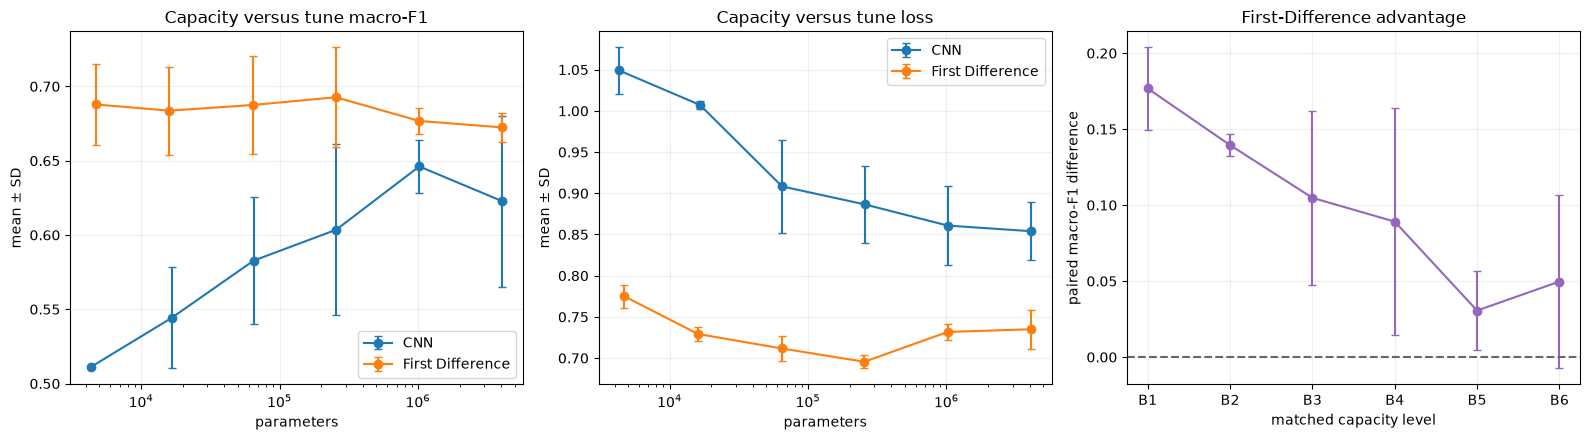

In [21]:
figure, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for family, family_summary in capacity_summary.groupby("family"):
    family_summary = family_summary.set_index("capacity_level").loc[list(CAPACITY_LEVELS)]
    label = "First Difference" if family == "first_difference" else "CNN"
    axes[0].errorbar(
        family_summary["parameter_count"], family_summary["tune_macro_f1_mean"],
        yerr=family_summary["tune_macro_f1_std"], marker="o", capsize=3,
        label=label,
    )
    axes[1].errorbar(
        family_summary["parameter_count"], family_summary["tune_loss_mean"],
        yerr=family_summary["tune_loss_std"], marker="o", capsize=3,
        label=label,
    )
axes[0].set(xscale="log", title="Capacity versus tune macro-F1", xlabel="parameters", ylabel="mean ± SD")
axes[1].set(xscale="log", title="Capacity versus tune loss", xlabel="parameters", ylabel="mean ± SD")
advantage_plot = capacity_advantage_summary.set_index("capacity_level").loc[list(CAPACITY_LEVELS)]
axes[2].errorbar(
    np.arange(len(CAPACITY_LEVELS)), advantage_plot["macro_f1_advantage_mean"],
    yerr=advantage_plot["macro_f1_advantage_std"], marker="o", capsize=3,
    color="tab:purple",
)
axes[2].axhline(0, color="0.4", linestyle="--")
axes[2].set(
    title="First-Difference advantage", xlabel="matched capacity level",
    ylabel="paired macro-F1 difference", xticks=np.arange(len(CAPACITY_LEVELS)),
    xticklabels=CAPACITY_LEVELS,
)
for axis in axes:
    axis.grid(alpha=0.2)
axes[0].legend(); axes[1].legend(); figure.tight_layout()

### Interpretation

First Difference is substantially more parameter-efficient than the standard CNN under the shared protocol. At B1, roughly 4.5 thousand parameters, its mean tune macro-F1 is $0.688 \pm 0.027$ versus $0.511 \pm 0.001$ for the CNN, a paired advantage of $0.177 \pm 0.027$. At B4, roughly 256 thousand parameters, the means are $0.693 \pm 0.034$ and $0.604 \pm 0.058$, an advantage of $0.089 \pm 0.075$. First Difference has lower tune loss for every seed at all six budgets and higher macro-F1 for every seed through B5. At B6 it wins macro-F1 for two of three seeds, so the high-capacity advantage is less stable.

The efficiency gain comes mainly from the architecture rather than from continued scaling. First Difference reaches its lowest mean tune loss, 0.696, and highest mean macro-F1, 0.693, at B4. Increasing it to approximately 1.02 and 4.07 million parameters worsens mean tune loss to 0.732 and 0.735 while the mean train–tune Macro-F1 gap rises from 0.053 to 0.063 and 0.085. The CNN improves more gradually and reaches its best mean macro-F1, 0.646, near 1.02 million parameters, but even that remains below the 4.7-thousand-parameter First-Difference mean of 0.688.

The study therefore confirms a large capacity-efficiency advantage for the tested First-Difference template on this dataset, especially below one million parameters. It does not support assigning First Difference more capacity: its observed optimum is near 255 thousand parameters and larger variants show saturation with increasing overfitting. The conclusion is specific to the shared optimizer protocol, selected templates, three seeds and repeatedly used tune fold; it is not a universal parameter-efficiency claim.

<a id="candidate-artifacts"></a>
## 9. Candidate artifacts

In [15]:
candidate_histories, candidate_models, candidate_paths = {}, {}, {}
for trial in architecture_trials:
    architecture = trial.params["model.architecture"]
    training_config = TrainingConfig(**trial.user_attrs["training_config"])
    model, parameter_count = create_model(
        ExtendedCNNClassifier, input_length=train_fold.features.shape[-1],
        num_classes=len(preprocessor.class_names), random_seed=42,
        **trial.user_attrs["model_config"],
    )
    history = fit_model(model, training_config, training_fold=train_fold, tuning_fold=tune_fold, device=device)
    restored, paths = save_and_verify_experiment(
        f"extended_cnn_{architecture}", model, history, preprocessor=preprocessor,
        training_fold=train_fold, tuning_fold=tune_fold, device=device,
    )
    candidate_models[architecture] = restored
    candidate_histories[architecture] = history
    candidate_paths[architecture] = paths
print("Reload-verified candidate artifacts:")
for architecture, paths in candidate_paths.items(): print(f"  {architecture}: {paths.model}")

model_config: {'input_length': 289, 'num_classes': 6, 'architecture': 'gated_fusion', 'branch_channels': (32, 64, 96), 'kernel_sizes': (5, 3, 3), 'dilations': (1, 2, 4), 'hidden_dims': (256,), 'dropout': 0.19035990126749178, 'adaptive_pool_size': 4, 'multi_scale_kernel_sizes': (3, 7, 15), 'ordinal_temperature': 1.0}
trainable parameters: 463,366
training_config: TrainingConfig(epochs=160, batch_size=64, learning_rate=0.00041565416435761297, weight_decay=0.0, scheduler_step_size=15, learning_rate_decay=0.8, scheduler_strategy='none', warmup_epochs=0, warmup_start_factor=0.1, minimum_learning_rate=1e-06, patience=25, report_every=20, random_seed=42, class_balance_strategy='weighted_loss', gradient_clip_norm=None)
epoch   1: train loss 1.14643, validation loss 1.19934, train accuracy 49.5%, validation accuracy 45.0%
epoch  20: train loss 0.46100, validation loss 0.74441, train accuracy 79.2%, validation accuracy 67.6%
epoch  40: train loss 0.30553, validation loss 0.76288, train accuracy 

### Interpretation: exported models

All seven per-architecture proposals are retrained with seed 42, restored at their minimum tune-loss epochs, serialized and reloaded successfully. The resulting top-level artifacts contain the model weights, training history, preprocessing statistics, class names and exact model/training configuration. Parameter counts range from 44,902 for multi-scale to 839,238 for TCN.

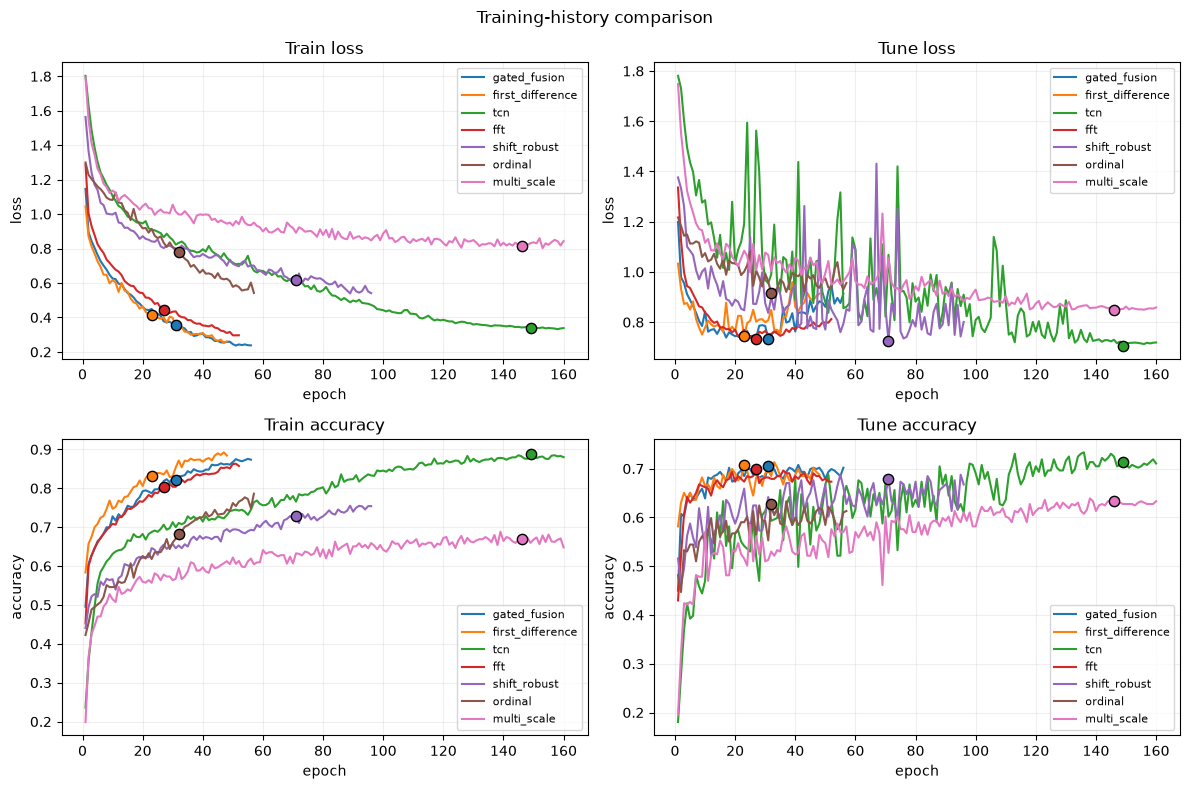

In [16]:
history_figure = plot_history_comparison(candidate_histories)

### Interpretation: exported training histories

The exported gated-fusion, first-difference and FFT runs restore early checkpoints at epochs 31, 23 and 27. Shift robust restores epoch 71, whereas multi-scale and TCN continue to epochs 146 and 149. The early optima and later train–tune separation of the leading compact models show that optimization capacity is already sufficient to fit the training data; their limiting issue is held-out generalization rather than an inability to reduce training loss. Small differences from the original Optuna executions can remain because the GPU path is not configured for strict deterministic replay.

Tune-only diagnostic for the leading confirmed architecture: first_difference
              precision    recall  f1-score   support

         0pM       0.45      0.94      0.61        36
         1pM       0.75      0.50      0.60        78
       2.5pM       0.75      0.76      0.75        66
         5pM       0.73      0.56      0.64        62
        25pM       0.84      0.79      0.81        72
       100pM       0.82      0.91      0.86        35

    accuracy                           0.71       349
   macro avg       0.72      0.75      0.71       349
weighted avg       0.74      0.71      0.71       349



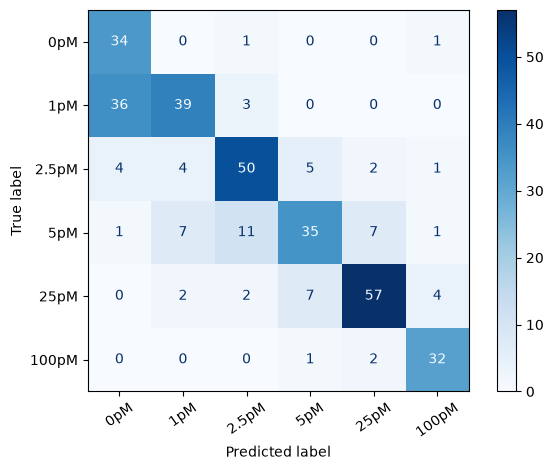

In [17]:
leading_architecture = confirmation_summary["tune_macro_f1_mean"].idxmax()
print(f"Tune-only diagnostic for the leading confirmed architecture: {leading_architecture}")
leading_tune_metrics = evaluate_classifier(
    candidate_models[leading_architecture], tune_fold,
    class_names=preprocessor.class_names, device=device,
)

### Interpretation: leading tune report

First difference is the leading architecture by confirmed mean Macro-F1. Its exported seed-42 checkpoint reaches tune accuracy 0.708 and Macro-F1 0.713. Class F1 is highest for 100 pM (0.86) and 25 pM (0.81), intermediate for 2.5 pM (0.75) and 5 pM (0.64), and lowest for 0 pM (0.61) and 1 pM (0.60). The 0 pM class has high recall (0.94) but low precision (0.45), while 1 pM has only 0.50 recall. The error pattern is therefore concentrated among the lower-dose classes rather than uniformly distributed across the dose range.

### Artifact and evaluation scope

Seven reload-verified candidates are stored in top-level directories beginning with `extended_cnn_`. Screening tables, Optuna databases, MLflow records and confirmation histories remain under `artifacts/experiments/extended_cnns/` and are not discovered as deployable candidates by Notebook 03. The classification report and confusion matrix above use only the tune fold; no test observations enter this notebook.

<a id="conclusions"></a>
## 10. Conclusions

The controlled screening initially favors gated fusion at tune macro-F1 $0.713 \pm 0.007$, with first difference and FFT in the same broad leading tier. Joint hyperparameter search substantially improves the initially weaker shift-robust and ordinal variants, showing that part of the screening gap was caused by optimization and configuration rather than architecture alone.

Multi-seed confirmation ranks first difference first at $0.704 \pm 0.004$, followed by gated fusion at $0.697 \pm 0.019$ and shift robust at $0.694 \pm 0.008$. These differences are small relative to the observed seed variation, so the joint search identifies a competitive group rather than an unequivocal architecture winner. The leading first-difference artifact attains tune macro-F1 0.713 on its exported seed-42 run. Its class-level report is strongest for 25 pM and 100 pM and weakest for 0 pM and 1 pM.

The matched-capacity study resolves the main uncertainty raised by the standard-CNN scaling experiment. Under one shared training protocol, First Difference has lower tune loss at every tested parameter budget and for every confirmation seed. Its Macro-F1 advantage is largest at the smallest budget ($0.177 \pm 0.027$ near 4.5 thousand parameters), remains positive through approximately one million parameters for all seeds, and becomes less stable at four million parameters. First Difference reaches its own best mean tune loss and Macro-F1 near 255 thousand parameters; larger versions worsen both tune loss and the train–tune gap.

The observed First-Difference advantage is therefore a capacity-efficiency result, not evidence that the architecture needs more parameters. The raw-plus-derivative representation extracts useful signal at very small budgets, whereas the standard CNN relies more strongly on increasing width. The result is conditional on the selected templates, common learning-rate sweep, three seeds and reused tune fold, and it does not establish a universal architectural scaling law.

All reported selection and capacity evidence is tune-only. The test fold remains unopened here, and the reload-verified candidate artifacts provide the handoff to Notebook 03.